Mouse:
0.1
0.1
0.2
0.1
0.30000000000000004
0.1
0.4
0.1
0.5
0.1
0.6
0.1
0.7
0.1
0.7999999999999999
0.1
0.8999999999999999
0.1
0.9999999999999999
0.1
0.1
0.2
0.2
0.2
0.30000000000000004
0.2
0.4
0.2
0.5
0.2
0.1
0.30000000000000004
0.2
0.30000000000000004
0.30000000000000004
0.30000000000000004
0.1
0.4
0.2
0.4
0.30000000000000004
0.4
0.1
0.5
0.2
0.5
0.1
0.6
0.2
0.6
0.1
0.7
0.2
0.7
0.1
0.7999999999999999
0.2
0.7999999999999999
0.1
0.8999999999999999
Damping: 2.5518550688963973e-06
Frequency: 28.34093507974865


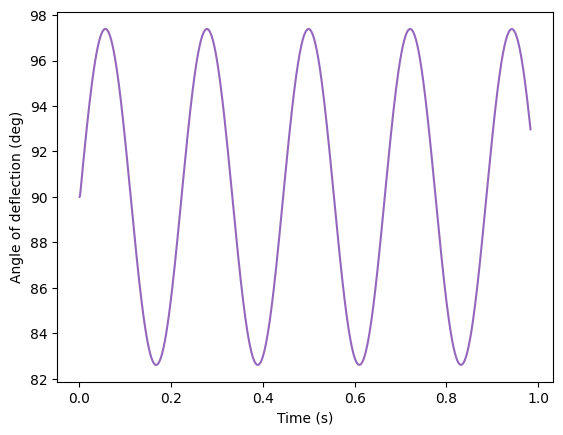

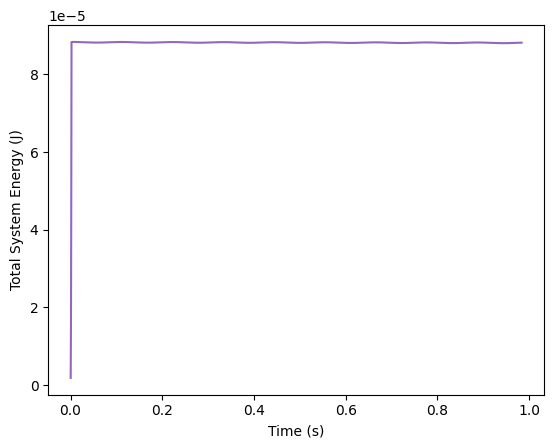

B value: 0.37188242583227954
B value: -0.3837441715078189


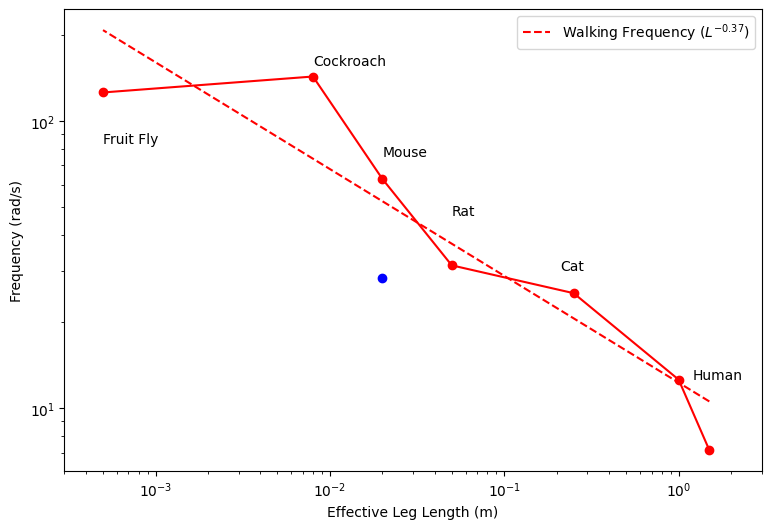

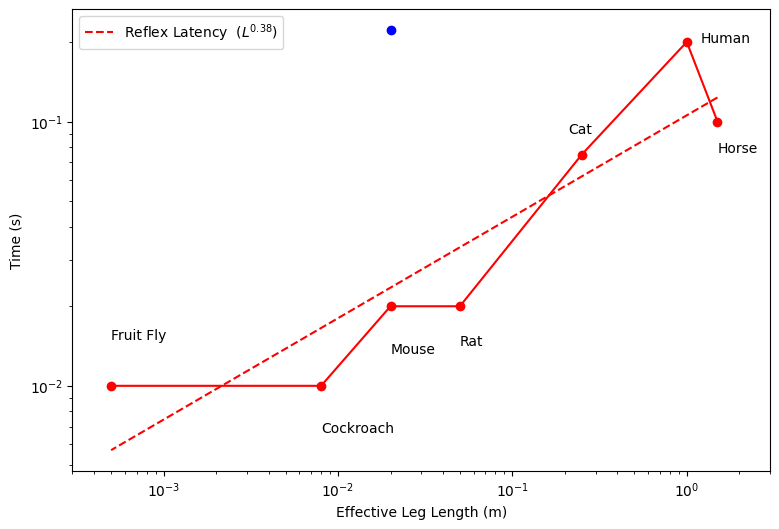

In [ ]:
# Import packages
import time
import itertools
import pandas as pd
import mujoco
import mediapy as media
import numpy as np
import math
import matplotlib.pyplot as plt

# Edit settings
showf = True  # Plot frequency vs leg length graphs
imp = True  # Apply impulsive perturbation (instead of setting initial velocity)
single = True  # Run each simulation once (Turn off to run a parameter sweep)
showVid = False  # Show video of simulation
layer = False  # Plot all data on a single plot
layer = layer and single
line = False  # Graphically show end of perturbation
ortho = False  # Show orthogonal view of model
wide = 0  # Set to 1 for splay-legged cockroach/fruit fly, 0 for straight legged
out = wide
damp = 0  # Set to 1 for damped models, 0 for undamped models
direct = 1  # Set to 0 for normal impulse scaling, set to 1 for individual impulse scaling based on model mass
seconds = 61  # Simulation time (Automatically set if greater than 60s)
speed = 1  # Video Speed (1 is normal speed, and can be increased or decreased)
vel_pert = 10  # Initial angular velocity of model when not perturbing with an impulse
reference = 1  # Model used as a reference for scaling impulse
Gmax = 5  # Perturbation accelleration of reference model
perturbationTime = 0.01  # Perturbation time of reference model
f = 1  # Factor (f) for parameter sweep step sizes
maximumforce = f
maximumtime = maximumforce
grav = 0  # Set to 1 to enable, or 0 to disable, gravity
timestep = 0.0003  # Default simulation timestep

num = [0, 1, 2, 3, 4, 5, 6]  # Models being used in current simulation

num_legs = [2, 1, 2, 2, 2, 3, 3, 1]  # Number of pairs of legs for each model
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]  # Model leg lengths
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7, 70]  # Model masses
max_time = [
    0.1,
    0.2,
    0.075,
    0.02,
    0.02,
    0.01,
    0.002,
]  # Maximum perturbation times, limited by reflex latency and natural half period of oscillation

hip_angi = [0, 0, 0, 0, 0, 0, 0, 0]  # Model hip swivel angle
knee_starti = [0, 0, 0, 0, 0, 65 * wide, 105 * wide, 0]  # Model knee starting angle
stance_width = [
    1,
    1,
    1,
    1,
    1,
    8 / (8 - 7 * wide),
    8 / (8 - 7 * wide),
    1,
]  # Mode stance widths, normalized by their hip widths
sec = [10, 10, 3, 3, 1, 0.5, 0.05, 3]  # Model simulation times
mag = [1, 1, 1, 1, 1, 100, 1000, 10000]  # Model scaling up factors

Mscale = [
    4.849,
    1,
    1.98,
    1.65,
    2.019,
    2.311,
    2.679,
    1,
]  # Current mass scaling for each model (Found using the last code block)
T_vec = [
    0.88,
    0.5,
    0.25,
    0.2,
    0.1,
    0.044,
    0.05,
]  # Minimum walking frequencies from Sutton et al.

# Model names and graphing colors
name = [
    "Horse",
    "Human",
    "Cat",
    "Rat",
    "Mouse",
    "Cockroach",
    "Fruit Fly",
]
color = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
]

# Set up perturbation forces
max_force = []
for i in range(len(Mi)):
    max_force.append(Mi[i] * Gmax * 9.81)
enerG = [[], [], [], [], [], [], [], []]
t_scale = [[], [], [], [], [], [], [], []]
maxangle = 0

# Plot scaling for layered view
if layer:
    e = 0.5 * 103.7 * 2
    sec = [
        e / 1.773,
        e / 3,
        e / 7.627,
        e / 10.23,
        e / 28.38,
        e / 103.7,
        e / 2613,
        e / 3,
    ]

# Do not run a parameter sweep if multiple models are selected
if len(num) > 1:
    single = True

# Declare a few variables for later use
time_scale = [1, 1, 1, 1, 1, 1, 1, 1]
perti = [1, 1, 1, 1, 1, 1, 1, 1]

# Scale perturbation with leg length
perti[reference] = max_force[reference]
time_scale[reference] = perturbationTime
for digit in num:
    mass_scale = 1.5 + 0.5 * (2.63936751 * (1 - direct) + Mscale[digit] * direct)
    time_scale[digit] = time_scale[reference] * (Li[digit] / Li[reference]) ** (
        mass_scale - 2
    )
    perti[digit] = perti[reference] * (Li[digit] / Li[reference]) ** (
        2 * 1 + mass_scale * 0
    )

# Find walking frequencies
w_frequency, n_frequency, Li_mod = [], [], []
for c in T_vec:
    w_frequency.append(2 * math.pi / c)
if ortho == True:
    xy = "1 1 0 0 0 1"
    offset = 25 * (1 + out / 2)
else:
    xy = "1 0 0 0 0 1"
    offset = 1


# Findpeaks code
def getFrequency(t, a):
    if damp == 1 and (i == 6):
        return 2613
    elif damp == 1 and out != 0 and i == 5:
        return 103.7
    first_peak = 0
    second_peak = 0
    y = 100
    count = int(len(t) / 3)
    pos = -1
    while count < len(t) * 2 / 3:
        if a[count] == max(a[count - y : count + y]):
            first_peak = count
            count += y
            break
        count += 1
    if a[first_peak] > ank_start:
        pos = 1
    while count < len(t):
        if (
            a[count] == max(a[count - y : count + y])
            and a[count] * pos > ank_start * pos
        ):
            second_peak = count
            break
        count += 1
    print(
        "Damping: "
        + str(
            abs(
                math.log(a[first_peak] / a[second_peak])
                / math.sqrt(
                    (2 * math.pi) ** 2 + math.log(a[first_peak] / a[second_peak]) ** 2
                )
            )
        )
    )
    return abs(1 / (t[first_peak] - t[second_peak]) * 2 * math.pi)


def getAngle(pos, q):
    return 180 - math.atan2(z_dist + pos[2], pos[0]) * 180 / math.pi


# Iterate through simulation
change = False
for i in num:
    if seconds > 60 or change == True:
        seconds = sec[i]
        change = True
    num_legsi = num_legs[i]
    print(name[i] + ":")
    scaler = 2
    L = Li[i] * mag[i]
    M = Mi[i] * mag[i]
    L_COM = 0.293 / 0.530 * L
    W = L * 0.134 / 0.530
    H = L * 0.108 / 0.530
    S = W * stance_width[i]

    # Set stiffness, damping, and inertial values
    hip_stiff = 12000 * 0.001 * math.pow(L, 3) * 8 / 0.29 / num_legsi * num_legsi
    knee_stiff = hip_stiff / 7
    Damp = 1.31e3 * 0.001 * L**3 / num_legsi * damp * num_legsi
    knee_damp = Damp / 7

    I_leg = 0.030 * M * math.pow(L / 0.530, 2) / num_legsi * num_legsi
    I_torso = 0.020 * M * math.pow(L / 0.530, 2)

    constraint_M = 1e-15
    constraint_I = 1e-15

    hip_ang = hip_angi[i]
    knee_start = knee_starti[i]

    # Set model positions
    x_dist = (S - W) / 2
    if S == W:
        y_dist = 0
    else:
        y_dist = x_dist * math.tan(hip_ang / 180 * math.pi)
    dist = math.sqrt(math.pow(x_dist, 2) + math.pow(y_dist, 2))
    ank_start = math.acos(dist / L) * 180 / math.pi + knee_start / 2
    hip_start = ank_start - knee_start
    L = L / math.sqrt((1 - math.cos((180 - knee_start) / 180 * math.pi)) / 2)
    z_dist = L / 2 * math.sin(ank_start / 180 * math.pi) + L / 2 * math.sin(
        (hip_start) / 180 * math.pi
    )
    lower_x_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.cos(hip_ang / 180 * math.pi)
    )
    lower_y_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.sin(hip_ang / 180 * math.pi)
    )
    lower_z_dist = L / 2 * math.sin(ank_start / 180 * math.pi)
    L_COM = 0.293 / 0.530 * L

    # Edit timesteps individually for cockroach and fruit fly
    if i >= 5:
        timestep /= 10
    if i >= 6:
        timestep /= 30
    if i == 7:
        timestep *= 300

    # Xml variables for extra legs
    weld = f"""
    solref = "{timestep/10} 1" 
    """
    rl1 = ""
    rl2 = ""
    ll1 = ""
    ll2 = ""
    weld1 = ""
    weld2 = ""
    lj = f"""
    <joint name="left_knee" type="hinge" axis="{math.sin(hip_ang*math.pi/180)} {math.cos(hip_ang*math.pi/180)} 0" pos="{lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj = f"""
    <joint name="right_knee" type="hinge" axis="{math.sin(-hip_ang*math.pi/180)} {math.cos(-hip_ang*math.pi/180)} 0" pos="{S-lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    lj1 = f"""
    <joint name="left_knee1" type="hinge" axis="0 1 0" pos="{lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj1 = f"""
    <joint name="right_knee1" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    lj2 = f"""
    <joint name="left_knee2" type="hinge" axis="0 1 0" pos="{lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj2 = f"""
    <joint name="right_knee2" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    ll = f"""
    <body name ="left_leg">
          <inertial pos="{L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip" type="hinge" axis="0 1 0" pos="{x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh" type="box" pos="{(lower_x_dist+x_dist)/2} {(lower_y_dist+y_dist)/2} {(lower_z_dist+z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left">
            {lj*out}
            <geom name="left_shank" type="box" pos="{lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left">
              <inertial pos = "0 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle" type="ball" pos="0 0 0" stiffness="0" damping="0"/>
              <body name = "left_foot">
                <geom name="left_f" pos="0 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
    rl = f"""
    <body name ="right_leg">
          <inertial pos="{S-L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip" type="hinge" axis="0 1 0" pos="{S-x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh" type="box" pos="{S-(x_dist+lower_x_dist)/2} {(y_dist+lower_y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right">
            {rj*out}
            <geom name="right_shank" type="box" pos="{S-lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right">
              <inertial pos = "{S} 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle" type="ball" pos="{S} 0 0" stiffness="0" damping="0"/>
              <body name = "right_foot">
                <geom name="right_f" pos="{S} 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
    if num_legs[i] > 1:
        rl1 = f"""
        <body name ="right_leg1">
          <inertial pos="{S-L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip1" type="hinge" axis="0 1 0" pos="{S-x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh1" type="box" pos="{S-(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right1">
            {rj1*out}
            <geom name="right_shank1" type="box" pos="{S-lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right1">
              <inertial pos = "{S} {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle1" type="hinge" pos="{S} {L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot1">
                <geom name="right_f1" pos="{S} {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll1 = f"""
        <body name ="left_leg1">
          <inertial pos="{L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip1" type="hinge" axis="0 1 0" pos="{x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh1" type="box" pos="{(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left1">
            {lj1*out}
            <geom name="left_shank1" type="box" pos="{lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left1">
              <inertial pos = "0 {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle1" type="hinge" pos="0 {L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot1">
                <geom name="left_f1" pos="0 {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld1 = f"""
      <weld body1 ="right_foot1" body2 ="world" anchor="{S} {L/3} 0" {weld}/>
      <weld body1 ="left_foot1" body2 ="world" anchor="0 {L/3} 0" {weld}/>
    """
    if num_legs[i] > 2:
        rl2 = f"""
        <body name ="right_leg2">
          <inertial pos="{S-L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip2" type="hinge" axis="0 1 0" pos="{S-x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh2" type="box" pos="{S-(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right2">
            {rj2*out}
            <geom name="right_shank2" type="box" pos="{S-lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right2">
              <inertial pos = "{S} {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle2" type="hinge" pos="{S} {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot2">
                <geom name="right_f2" pos="{S} {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll2 = f"""
        <body name ="left_leg2">
          <inertial pos="{L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip2" type="hinge" axis="0 1 0" pos="{x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh2" type="box" pos="{(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left2">
            {lj2*out}
            <geom name="left_shank2" type="box" pos="{lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left2">
              <inertial pos = "0 {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle2" type="hinge" pos="0 {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot2">
                <geom name="left_f2" pos="0 {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld2 = f"""
      <weld body1 ="right_foot2" body2 ="world" anchor="{S} {2*L/3} 0" {weld}/>
      <weld body1 ="left_foot2" body2 ="world" anchor="0 {2*L/3} 0" {weld}/>
    """

    # Create general xml file
    xml = f"""
  <?xml version="2.0" ?>
  <mujoco>
    <option>
        <flag energy="enable" refsafe = "enable"/>
    </option>
    <option integrator="RK4" gravity="0 0 {-9.81*grav}" timestep="{timestep}" viscosity = "0" density = "0" o_friction="0 0 0 0 0"/>
    <compiler eulerseq = "zyx"/>
    <worldbody>
      <light name="top" pos="0 0 {5*L}"/>
      <camera name="fixed" pos="{offset*W/2} {-3*L} {z_dist/2}" xyaxes="{xy}"/>
      <body name="model">
        "{ll}"
        "{ll1}"
        "{ll2}"
        <freejoint/>
        <body name="torso">
          <geom name="pelvis" type="box" pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" size="{W/2} {0.005*L*num_legs[i]+L/6*(num_legs[i]-1)} {H}" rgba="1 1 0 1" mass = "{3/4*M}"/>
          <inertial pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" mass = "{3/4*M}" diaginertia="{I_torso} {I_torso} {I_torso}"/>
        </body>
        "{rl}"
        "{rl1}"
        "{rl2}"
      </body>
    </worldbody>
    <equality>
      <weld body1 ="right_foot" body2 ="world" anchor="{S} 0 0" {weld}/>
      <weld body1 ="left_foot" body2 ="world" anchor="0 0 0" {weld}/>
      "{weld1}"
      "{weld2}"
    </equality>
  </mujoco>
  """

    force, time_s, amp, vamp, values = [], [], [], [], []
    done = False
    finished = False
    mforce = maximumforce * mag[i] ** scaler
    mtime = maximumtime

    # Find maxangle
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)
    n_frames = 60 * seconds
    height = 480
    width = 640
    fps = 60.0
    pert_time = 0.01
    frames, angle, times = [], [], []
    pert_angle, pert_times, pert_height = [], [], []
    renderer = mujoco.Renderer(model, height, width)
    mujoco.mj_resetData(model, data)
    N = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")

    # Get maximum angle of deflection
    if imp == True:
        data.xfrc_applied[N] = [perti[i] * mag[i] ** scaler, 0, 0, 0, 0, 0]
        while maxangle == 0:

            mujoco.mj_step(model, data)
            pert_angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
            pert_times.append(data.time)
            pert_height.append(data.xpos[N][2])
            COM = data.xipos[N][0]
            if layer:
                maxangle = 97.3
            if data.time > 0.02 and i > 4:
                maxangle = 97.3
            if COM > S:
                angle = getAngle(data.xpos[N], data.geom_xmat[1][2])
                maxangle = angle
        maxImp = perti[i] * mag[i] ** scaler * data.time
        factor = math.ceil(len(pert_times) / 50000)
    min_time = maxImp / max_force[i]
    min_force = maxImp / max_time[i]

    if single:
        pert_time = time_scale[i]
        max_time[i] = 1
    else:
        perti[i] = max_force[i]
        pert_time = max_time[i]
    while finished == False:
        finished = single
        done = False
        mtime = maximumtime
        while done == False:
            done = single

            # Run simulation
            model = mujoco.MjModel.from_xml_string(xml)
            data = mujoco.MjData(model)
            n_frames = 60 * seconds
            height = 480
            width = 640
            fps = 60.0 / speed
            frames, angle, times, energy = [], [], [], []
            pot, kin = [], []
            renderer = mujoco.Renderer(model, height, width)

            mujoco.mj_resetData(model, data)
            N = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")

            # Apply perturbation impulse
            if imp == True:
                data.xfrc_applied[N] = [perti[i] * mforce, 0, 0, 0, 0, 0]
                counter = 0
                while data.time < pert_time * mtime:
                    counter = counter + 1
                    mujoco.mj_step(model, data)
                    times.append(data.time)
                    angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
                    energy.append(data.energy[0] + data.energy[1])
                if showVid:
                    renderer.update_scene(data, "fixed")
                    frame = renderer.render()
                    frames.append(frame)
                vel = float(data.qvel[0])
                vamp.append(vel)
                force.append(perti[i] * mforce)
                time_s.append(pert_time * mtime)
                data.xfrc_applied[N] = [0, 0, 0, 0, 0, 0]
            else:
                data.qvel[4] = vel_pert

            # Simulate reaction to perturbation
            for j in range(int(n_frames)):
                while data.time < j / fps:
                    mujoco.mj_step(model, data)
                    times.append(data.time)
                    angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
                    energy.append(data.energy[0] + data.energy[1])
                if showVid:
                    renderer.update_scene(data, "fixed")
                    frame = renderer.render()
                    frames.append(frame)

            amp.append(max(angle))
            if max(angle) > maxangle or mtime > 1:
                done = True
            else:
                values.append(
                    [
                        perti[i] * mforce / mag[i] ** scaler,
                        pert_time * mtime,
                        vel,
                        max(angle[int(len(angle) / 3) : len(angle)]),
                        perti[i] * mforce * pert_time * mtime / mag[i] ** scaler,
                    ]
                )
            if single == False:
                print(mtime)
                print(mforce)
            mtime = mtime + maximumtime
        if mtime == maximumtime * 2 or mforce > mag[i] ** scaler:
            finished = True
        mforce = mforce + maximumforce * mag[i] ** scaler

    # Plot simulation
    if single == True and layer == False:
        plt.title("Maximum Angle of Deflection = " + str(max(angle)))

    if showf == True:
        f = getFrequency(times, angle)
        print("Frequency: " + str(f))
        n_frequency.append(f)
    Li_mod.append(Li[i])
    if showVid:
        media.show_video(frames, fps=fps)

    factor = math.ceil(len(times) / 50000)
    ax = plt.subplots

    if layer == False:
        plt.xlabel("Time (s)")
        plt.ylabel("Angle of deflection (deg)")
        plt.plot(
            times[int(len(times) / 20) * 0 : len(times)][::factor],
            angle[int(len(angle) / 20) * 0 : len(angle)][::factor],
            color=color[i],
        )
        if line:
            plt.axvline(
                x=pert_time, color="black", linestyle="--", label="End of Perturbation"
            )
            plt.legend(loc="upper right")
        plt.show()

        plt.plot(
            times[int(len(times) / 20) * 0 : len(times)][::factor],
            energy[int(len(energy) / 20) * 0 : len(energy)][::factor],
            color=color[i],
        )
        plt.xlabel("Time (s)")
        plt.ylabel("Total System Energy (J)")
        if line:
            plt.axvline(
                x=pert_time, color="black", linestyle="--", label="End of Perturbation"
            )
            plt.legend(loc="upper right")
        plt.show()

    elif layer == True:
        maxE = max(energy)
        for j in range(len(times)):
            t_scale[i].append(
                times[j] * n_frequency[len(n_frequency) - 1] / 2 / math.pi
            )
            enerG[i].append(energy[j] / maxE)
        print("MaxTime = " + str(times[len(times) - 1]))
        print(
            "ChangedTime = "
            + str(times[len(times) - 1] * n_frequency[len(n_frequency) - 1])
        )
        print(
            "MaxPertime = "
            + str(pert_time * n_frequency[len(n_frequency) - 1] / 2 / math.pi)
        )

        # Remove half the data up to a certain point
        if len(n_frequency) == 1:
            mid = t_scale[i][len(t_scale[i]) - 1] / 5
            print(mid)
        j = 0
        while t_scale[i][j] < mid:
            j += 1
        t_scale[i] = t_scale[i][0:j]
        angle = angle[0:j]
        enerG[i] = enerG[i][0:j]
        if i == 7:
            ls = "dashed"
        else:
            ls = "solid"
        plt.plot(
            t_scale[i][int(len(t_scale[i]) / 20) * 0 : int(len(t_scale[i]))][::factor],
            angle[int(len(angle) / 20) * 0 : int(len(angle))][::factor],
            label=(name[i]),
            color=color[i],
            linestyle=ls,
            linewidth=10 - i,
        )
        plt.xlabel("Time/Period")
        plt.ylabel("Angle of deflection (deg)")

# Plot layered data
if layer == True:
    plt.legend(loc="lower left")
    plt.show()
    for i in num:
        if i == 7:
            ls = "dashed"
        else:
            ls = "solid"
        plt.plot(
            t_scale[i][int(len(t_scale[i]) / 20) * 0 : len(t_scale[i])][::factor],
            enerG[i][int(len(enerG[i]) / 20) * 0 : len(enerG[i])][::factor],
            label=(name[i]),
            linestyle=ls,
            linewidth=10 - i,
            color=color[i],
        )
    plt.xlabel("Time/Period")
    plt.ylabel("Total System Energy/Max System Energy")
    plt.legend(loc="lower left")
    plt.show()

if showf == True:

    # Plot walking frequency and natural frequency
    x1 = [1, 1.2, 1 / 1.2, 1, 1, 1, 1]
    y1 = [1 / 1.4, 1, 1.2, 1.5, 1.2, 1.1, 1 / 1.5]
    x2 = [1, 1.2, 1 / 1.2, 1, 1, 1, 1]
    y2 = [1 / 1.3, 1, 1.2, 1 / 1.4, 1 / 1.5, 1 / 1.5, 1.5]
    fig, ax = plt.subplots(figsize=(9, 6))
    plt.xlabel("Effective Leg Length (m)")
    plt.ylabel("Frequency (rad/s)")
    plt.scatter(Li, w_frequency, color="red")
    plt.loglog(
        Li,
        10
        ** (
            np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))(
                np.log10(Li)
            )
        ),
        linestyle="dashed",
        color="red",
        label=r"Walking Frequency ($L^{-0.37}$)",
    )
    a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))
    print("B value: " + str(-a))
    plt.loglog(
        Li,
        10
        ** (
            np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=6))(
                np.log10(Li)
            )
        ),
        color="red",
    )
    plt.scatter(Li_mod, n_frequency, color="blue")
    if len(n_frequency) > 1:
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))(
                    np.log10(Li_mod)
                )
            ),
            linestyle="dashed",
            color="blue",
            label=r"Natural Frequency ($L^{-0.85}$)",
        )
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(
                    np.polyfit(
                        np.log10(Li_mod),
                        np.log10(n_frequency),
                        deg=len(n_frequency) - 1,
                    )
                )(np.log10(Li_mod))
            ),
            color="blue",
        )
        a, b = np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))
        print("B value: " + str(-a))
        # print(b)s
    for i, txt in enumerate(name):
        ax.annotate(txt, (Li[i] * x1[i], w_frequency[i] * y1[i]))
    plt.xlim(3e-4, 3)
    plt.legend()

    # Plot reflex latency and natural periods
    latency = [0.1, 0.2, 0.075, 0.02, 0.02, 0.01, 0.01]
    late = []
    nPeriod = []
    count = 0
    for i in num:
        late.append(latency[i])
        nPeriod.append(2 * math.pi / n_frequency[count])
        count = count + 1
    late = latency
    fig, ax = plt.subplots(figsize=(9, 6))
    plt.xlabel("Effective Leg Length (m)")
    plt.ylabel("Time (s)")
    plt.scatter(Li, late, color="red")
    plt.loglog(
        Li,
        10
        ** (np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=1))(np.log10(Li))),
        linestyle="dashed",
        color="red",
        label=r"Reflex Latency  ($L^{0.38}$)",
    )
    a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=1))
    print("B value: " + str(-a))
    plt.loglog(
        Li,
        10
        ** (np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=6))(np.log10(Li))),
        color="red",
    )
    plt.scatter(Li_mod, nPeriod, color="blue")
    if len(nPeriod) > 1:
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(nPeriod), deg=1))(
                    np.log10(Li_mod)
                )
            ),
            linestyle="dashed",
            color="blue",
            label=r"Natural Period ($L^{0.85}$)",
        )
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(
                    np.polyfit(
                        np.log10(Li_mod),
                        np.log10(nPeriod),
                        deg=len(nPeriod) - 1,
                    )
                )(np.log10(Li_mod))
            ),
            color="blue",
        )
        a, b = np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(nPeriod), deg=1))
        print("B value: " + str(-a))
        # print(b)s
    for i, txt in enumerate(name):
        ax.annotate(txt, (Li[i] * x2[i], latency[i] * y2[i]))
    plt.xlim(3e-4, 3)
    plt.legend()

In [ ]:
import csv


list_outp = [["Force", "Time", "Velocity", "Amplitude", "Impulse"]]
for i in range(len(values)):
    list_outp.append(values[i])

# Store data from previous parameter sweep in csv file
with open("1dampFly.csv", "w") as csv_file:
    writer = csv.writer(csv_file)
    for row in list_outp:
        writer.writerow(row)

'Mass scaling: 2.6393675096190674'

'horseDamp.csv'

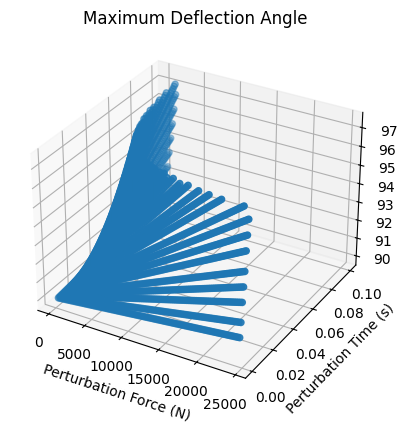

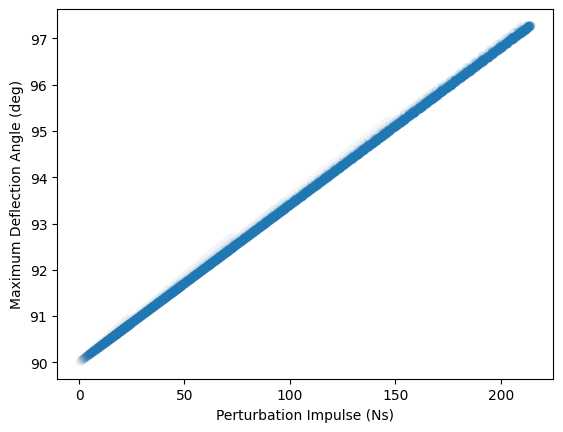

'dampHuman.csv'

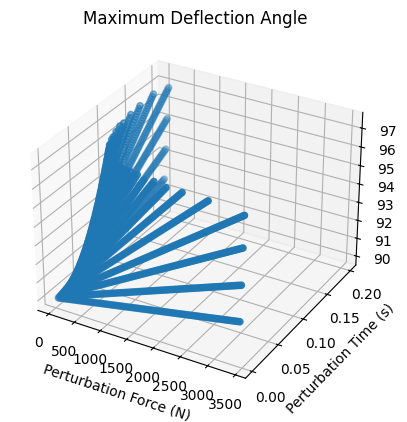

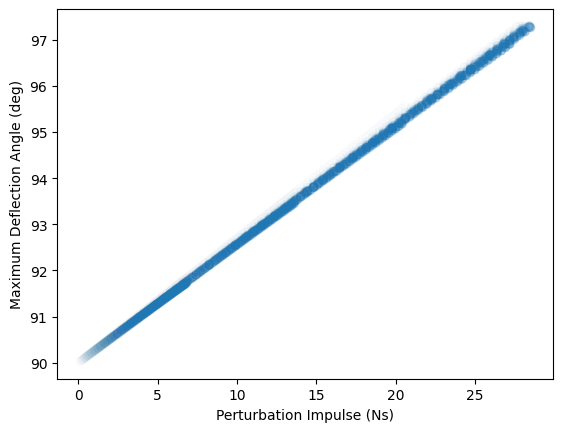

'catDamp.csv'

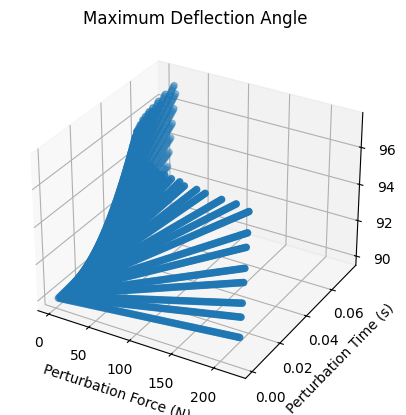

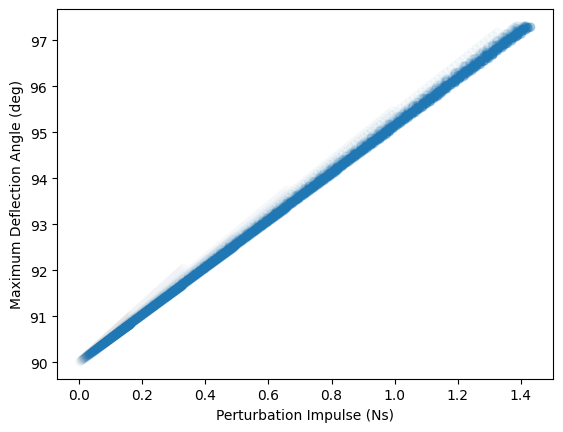

'ratDamp.csv'

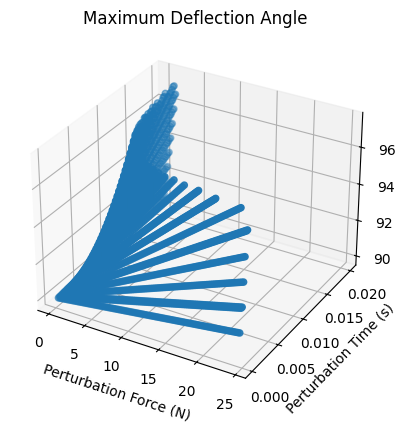

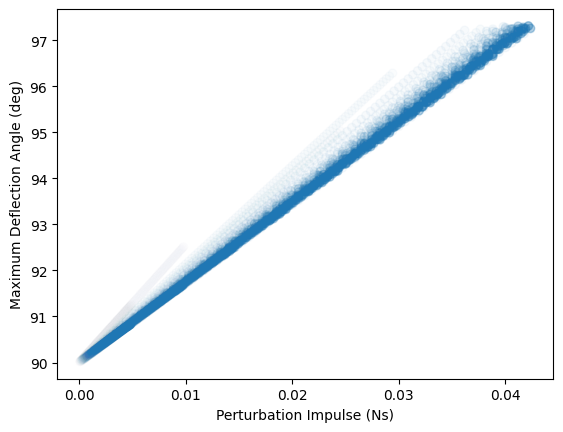

'mouseDamp.csv'

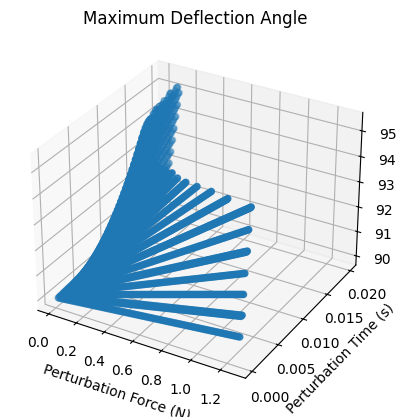

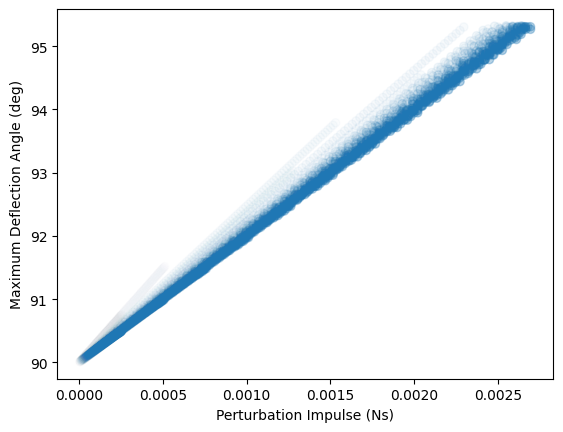

'cockroachDamp.csv'

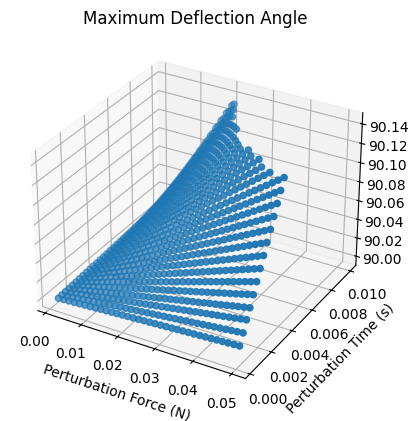

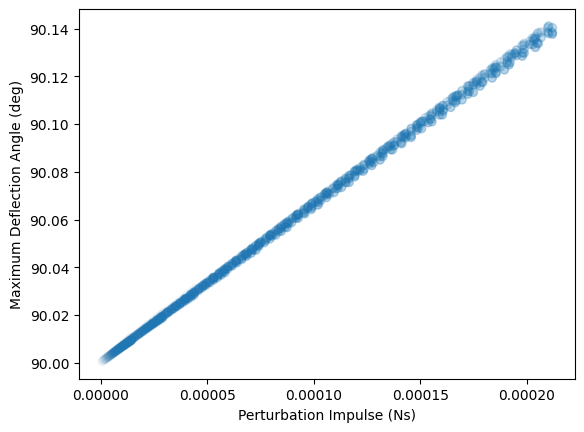

'flyDamp.csv'

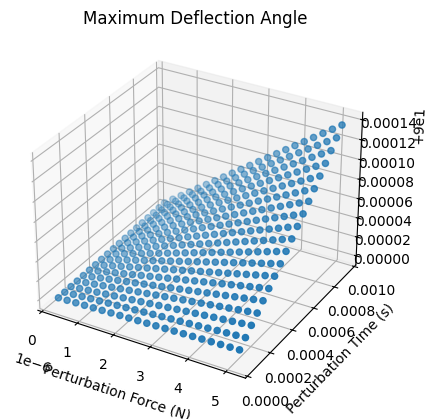

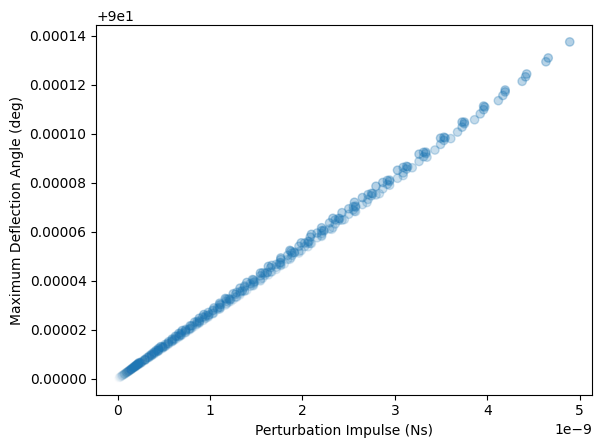

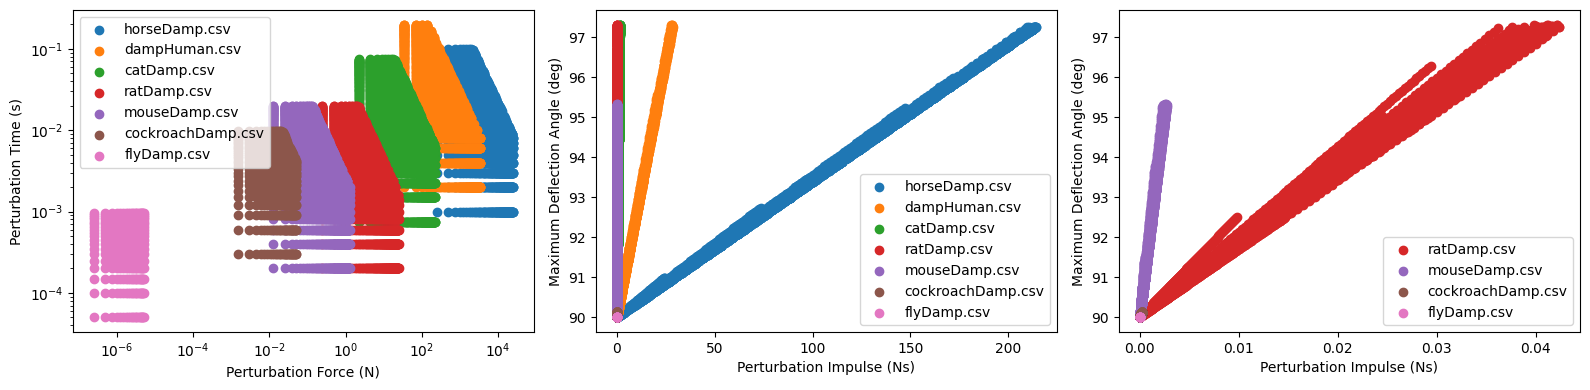

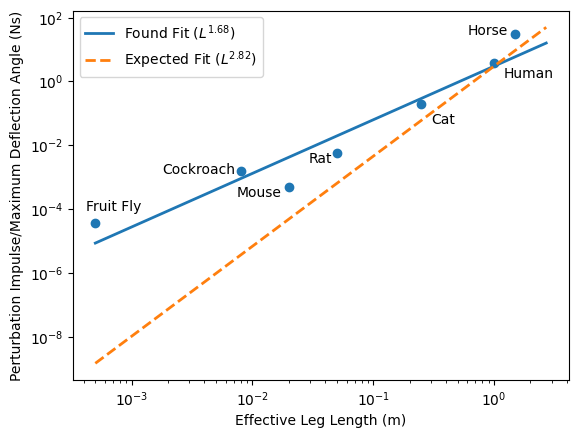

In [ ]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib import cm
from scipy.optimize import curve_fit

# Model masses and leg lengths
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7]
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
Length, Mass = [], []
number = [0, 1, 2, 3, 4, 5, 6]

# Select which set of data to analyze
# 1: Single pair of legs undamped
# 2: Undamped
# 3: Damped
# 4: Wide undamped
# 5: Wide damped
n1 = 1

for i in number:
    Length.append(Li[i])
    Mass.append(Mi[i])

slope = []


def line(x, m, b):
    return m * x + b


def exponent(x, m, b, c):
    return m * np.pow(x, b) + c


def logfit(x, m, b):
    return b * np.log10(x) + m


def testfit(x, a, b):
    return a * x**b


def reverseLog(x, m, b):
    return 10 ** (m * x + b)


# Scale mass
fit = np.polyfit(np.log10(Length), np.log10(Mass), 1)
display("Mass scaling: " + str(fit[0]))
test = 1.5 + fit[0] / 2

# Create sets of models to analyze
if n1 == 1:
    names = [
        "horse1.csv",
        "human1.csv",
        "cat1.csv",
        "rat1.csv",
        "mouse1.csv",
        "cockroach1.csv",
        "fly1.csv",
    ]
    fact = [1.2, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 4.5, 1.2]
    yfact = [1, 1, 1, 1, 1, 1, 1]
elif n1 == 2:
    names = [
        "horseUndamp.csv",
        "human1.csv",
        "catUndamp.csv",
        "ratUndamp.csv",
        "mouseUndamp.csv",
        "cockroachUndamp.csv",
        "flyUndamp.csv",
    ]
    fact = [1.3, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 4.5, 1.2]
    yfact = [1, 1, 1, 1, 1, 1, 1]
elif n1 == 3:
    names = [
        "horseDamp.csv",
        "dampHuman.csv",
        "catDamp.csv",
        "ratDamp.csv",
        "mouseDamp.csv",
        "cockroachDamp.csv",
        "flyDamp.csv",
    ]
    fact = [1 / 2.5, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 4.5, 1 / 1.2]
    yfact = [1, 1 / 3, 1 / 4, 1 / 2, 1 / 2, 1 / 1.2, 2.5]
elif n1 == 4:
    names = [
        "horseUndamp.csv",
        "human1.csv",
        "catUndamp.csv",
        "ratUndamp.csv",
        "mouseUndamp.csv",
        "cockroachWide.csv",
        "flyWideFix.csv",
    ]
    fact = [1.2, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 5, 1.2]
    yfact = [1 / 1.1, 1, 1 / 1.2, 1, 1, 1, 1]
elif n1 == 5:
    names = [
        "horseDamp.csv",
        "dampHuman.csv",
        "catDamp.csv",
        "ratDamp.csv",
        "mouseDamp.csv",
        "cockroachWideDampFix.csv",
        "flyWideDampFix.csv",
    ]
    fact = [1 / 2.5, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 4.5, 1 / 1.2]
    yfact = [1, 1 / 3, 1 / 3, 1 / 3, 1 / 3.5, 1 / 1.2, 5.5]

# Create arrays to store data
X, Y, Z, t, alpha, angle, force, s, imp, scaleimp = (
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
)
tfit, ffit = [], []

# Analyze data
for j in range(len(names)):
    alpha.append([])
    X.append([])
    Y.append([])
    Z.append([])
    t.append([])
    angle.append([])
    force.append([])
    s.append([])
    imp.append([])
    scaleimp.append([])
    fileName = names[j]
    data = []
    with open(fileName, "r") as csv_file:
        csv_reader = csv.reader(csv_file)
        for rows in csv_reader:
            data.append(rows)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    for i in range(len(data) - 1):
        X[j].append(float(data[i + 1][0]))  ##4
        Y[j].append(float(data[i + 1][1]))  # 3
        Z[j].append(float(data[i + 1][3]))  # 2 #4
        t[j].append(float(data[i + 1][1]))  # DO NOT CHANGE
        imp[j].append(float(data[i + 1][4]))
        scaleimp[j].append(float(data[i + 1][4]) * 1e6)
        angle[j].append(float(data[i + 1][3]))
        force[j].append(float(data[i + 1][0]))
        s[j].append(angle[j][i] / force[j][i])
    for i in range(len(data) - 1):
        alpha[j].append(float(data[i + 1][1]) / max(t[j]) / 3)
    display(fileName)
    ax.scatter(X[j], Y[j], Z[j])

    # Plot Perturbation forces and times
    plt.title("Maximum Deflection Angle")
    plt.xlabel("Perturbation Force (N)")
    plt.ylabel("Perturbation Time (s)")
    plt.show()

    # Plot angle of deflection vs perturbation impulse
    fig = plt.figure()
    ax = fig.add_subplot()
    x = X[j]
    y = Y[j]
    x = imp[j]
    y = angle[j]
    b, cov = curve_fit(line, y, scaleimp[j])
    slope.append(b[0] * 1e-6)
    ax.scatter(imp[j], angle[j], alpha=alpha[j])
    plt.xlabel("Perturbation Impulse (Ns)")
    plt.ylabel("Maximum Deflection Angle (deg)")
    plt.show()


# Plot both layered figures
fig = plt.figure(figsize=(16, 4))

# Plot layered perturbation forces and times
ax = fig.add_subplot(
    1,
    3,
    1,
)
for j in range(len(names)):
    ax.scatter(X[j], Y[j], label=(names[j][:]))  # -4
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlabel("Perturbation Force (N)")
plt.ylabel("Perturbation Time (s)")
plt.legend(loc="upper left")

# Plot layered angle of deflection vs perturbation impulse
ax = fig.add_subplot(1, 3, 2)
fit = np.polyfit(np.log10(Length), np.log10(slope), 1)
for j in range(len(names)):
    ax.scatter(imp[j], angle[j], label=(names[j][:]))

plt.xlabel("Perturbation Impulse (Ns)")
plt.ylabel("Maximum Deflection Angle (deg)")
plt.legend()
ax = fig.add_subplot(1, 3, 3)
n = 3
for j in range(len(names) - n):
    ax.scatter(
        imp[j + n], angle[j + n], label=(names[j + n][:]), color=color[j + n]
    )  # -4
plt.xlabel("Perturbation Impulse (Ns)")
plt.ylabel("Maximum Deflection Angle (deg)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot perturbation impulse/deflection angle vs leg length
fig = plt.figure()
ax = fig.add_subplot()
x_line = np.linspace(min(Length), max(Length) * 1.8)
ax.scatter(Length, slope)
ax.plot(
    x_line,
    reverseLog(np.log10(x_line), fit[0], fit[1]),
    label=r"Found Fit ($L^{" + str(round(fit[0], 2)) + r"}$)",
    linewidth=2,
)
ax.plot(
    x_line,
    reverseLog(np.log10(x_line), test * 1, fit[1]),
    label=r"Expected Fit ($L^{2.82}$)",
    ls="--",
    linewidth=2,
)
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Perturbation Impulse/Maximum Deflection Angle (Ns)")
ax.set_xscale("log")
ax.set_yscale("log")
for i, txt in enumerate(name):
    ax.annotate(txt, (Length[i] * fact[i], slope[i] * yfact[i]))
    arrowprops = dict(facecolor="black", shrink=0.05)
plt.legend()
plt.show()

2.6393675096190674


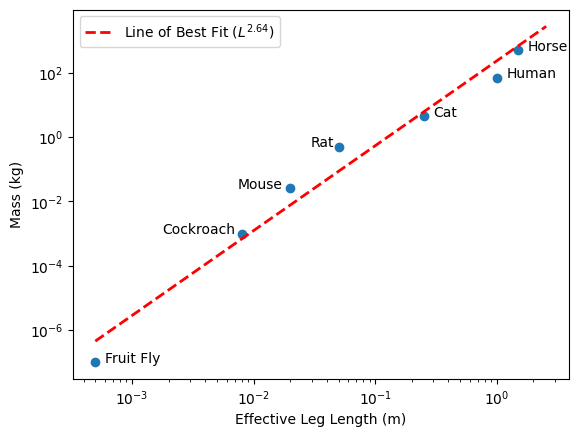

In [ ]:
# Code for scaling mass with leg length

Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7]  # Model masses
num = [2, 1, 2, 2, 2, 3, 3]  # Model number of sets of legs
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]  # Model leg lengths
Length, Mass = [], []
number = [0, 1, 2, 3, 4, 5, 6]  # Models used for scaling

# Uncomment the line of code below to see how number of legs scales with leg length
# Mi = num

for i in number:
    Length.append(Li[i])
    Mass.append(Mi[i])


def testfit(x, a, b):
    return a * x**b


# Plot mass vs leg length
fig = plt.figure()
ax = fig.add_subplot()
x_line = np.linspace(min(Length), max(Length) * 1.7)
ax.scatter(Length, Mass)
fit = np.polyfit(np.log10(Length), np.log10(Mass), 1)

# Print mass scaling
print(fit[0])

ax.plot(
    x_line,
    reverseLog(np.log10(x_line), fit[0], fit[1]),
    color="red",
    label=r"Line of Best Fit ($L^{2.64}$)",
    ls="--",
    linewidth=2,
)
x = [1.2, 1.2, 1.2, 1 / 1.7, 1 / 2.7, 1 / 4.5, 1.2]
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Mass (kg)")
ax.set_xscale("log")
ax.set_yscale("log")
for i, txt in enumerate(name):
    ax.annotate(txt, (Li[i] * x[i], Mass[i]))
    arrowprops = dict(facecolor="black", shrink=0.05)
plt.legend()
plt.show()